<a href="https://colab.research.google.com/github/ratatatan/itmo-oomd/blob/prac4/%D0%9A%D1%83%D1%80%D1%81_%D0%BD%D0%B0_Stepik_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Сделайте копию колаба (файл => создать копию на диске). Переименуйте, добавив в название ФИО и номер группы


# Модуль 5. Частотный анализ изображений

В документе есть ссылки на короткие видео с пояснениями и задание. Оригинально на Степике, это задание оценивалось через peer-review, то есть оценивали по критериям другие студенты. Сейчас этого делать не нужно. Поместите отчет о выполнении задания в конце.

## 5.1 JPEG. Преобразование Фурье. Склейка изображений



Видео урока:

* https://stepik.org/lesson/58410/step/1
* https://stepik.org/lesson/58410/step/2
* https://stepik.org/lesson/58410/step/3
* https://stepik.org/lesson/58410/step/4



## Задание

**Склейка изображений**

В этом задании вам предстоит научиться склеивать изображения с помощью преобразования Фурье.

1. Подготовьте одно изображение для экспериментов с гауссовской и лапласовской пирамидой.

2. Постройте гауссовскую пирамиду изображения из не менее чем пяти слоев. Визуализируйте полученные изображения и амплитуды частот изображений пирамиды (код можно найти в видео про преобразование Фурье) и убедитесь, что на каждом слое диапазон частот сужается. Постройте пирамиду для трех различных значения сигмы гауссовского ядра. Для удобства экспериментирования определите отдельную функцию построения гауссовской пирамиды с параметрами `img` (изображение, по которому строится пирамида), `sigma` (параметр гауссовского ядра), `n_layers` (количество слоев пирамиды), возвращающую списки необходимых изображений.

3. Проведите аналогичные эксперименты с лапласовской пирамидой. Функция для построения лапласовской пирамиды должна использовать функцию построения гауссовской пирамиды и иметь, как и функция гауссовской пирамиды, параметры `img`, `sigma` и `n_layers`.

4. На основе функций построения гауссовской и лапласовской пирамиды напишите функцию склейки двух изображений на основе маски. Функция должна возвращать склееные изображения и промежуточные результаты — склееные изображения разных частот (т.е. лапласовскую пирамиду совмещенного изображения). Изображения для тестирования: [a.png](https://stepik.org/media/attachments/lesson/58410/a.png) , [b.png](https://stepik.org/media/attachments/lesson/58410/b.png), [mask.png](https://stepik.org/media/attachments/lesson/58410/mask.png). Изображение с маской не является бинарным (т.е. имеет промежуточные градации серого), его можно бинаризовать путём сравнения всех элементов с порогом 128:


```
mask = imread('mask.png')
mask = (mask > 128).astype('uint')
```

Посмотрите, как ведет себя склейка при изменении `sigma` (попробуйте три варианта значений при фиксированном количестве слоев в пирамидах) и при изменении количества слоев (попробуйте три варианта слоев при фиксированном `sigma`). Склейка должна выдавать качественный результат без видимых артефактов хотя бы с одним набором параметров.

5. Подготовьте самостоятельно три набора изображений и масок для склейки и визуализируйте результаты функции. У вас должно получиться 3 качественных и интересных коллажа.


In [1]:
# 1 - 3
! wget -O trees.jpg -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/trees.jpeg
# 4
! wget -O a.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/eye.png
! wget -O b.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/hand.png
! wget -O mask.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/ellipse.png
# 5
! wget -O a_1.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/basketball.png
! wget -O b_1.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/fortune_teller.png
! wget -O mask_1.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/circle.png

! wget -O a_2.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/hair.png
! wget -O b_2.jpg -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/skull.jpg
! wget -O mask_2.jpg -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/hair_mask.jpg

! wget -O a_3.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/rider.png
! wget -O b_3.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/orbit.png
! wget -O mask_3.png -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/rider_mask.png

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

def show_grid(rows):
    n_rows = len(rows)
    n_cols = len(max(rows, key=len))
    plt.figure(figsize=(n_cols*3.5, n_rows*5))

    for y, row in enumerate(rows):
        for x, img in enumerate(row):
            plt.subplot(n_rows, n_cols, y * n_cols + x + 1)
            plt.imshow(img)

    plt.show()

In [3]:
import numpy as np
from skimage.color import rgb2ycbcr
from numpy.fft import fftshift, fft2
from skimage.transform import resize
from skimage.io import imread, imshow
from scipy.ndimage import gaussian_filter
from skimage import img_as_float, img_as_ubyte

def get_diff(images, convert_to_ubyte=False):
  images = [img_as_float(i) for i in images]
  return [
      images[i] - images[i-1]
      for i in range(1, len(images))
  ]

def get_gaussian_pyramid(
      img,
      sigma=1,
      n_layers=5,
    ):
    img = img_as_float(img)
    pyramid = [img]

    for _ in range(n_layers-1):
      if len(img.shape) == 2:
        node = np.clip(gaussian_filter(img, sigma), 0, 1)
      else:
        node = np.clip(
            np.dstack([
              gaussian_filter(img[:, :, c], sigma)
              for c in range(img.shape[2])
            ]),
        0, 1)
      pyramid.append(node)

    return pyramid

def get_laplacian_pyramid(
      img,
      sigma=1,
      n_layers=5,
      extend=False
    ):
    gaussian_pyramid = \
        get_gaussian_pyramid(img, sigma, n_layers)

    diff = get_diff(gaussian_pyramid)
    return diff if not extend else [*diff, gaussian_pyramid[-1]]

def freq(img, amplifier=20):
  ycbcr = rgb2ycbcr(img).astype(np.float32)
  return np.log(1 + abs(fftshift(fft2(ycbcr)))).astype(np.uint8) * amplifier

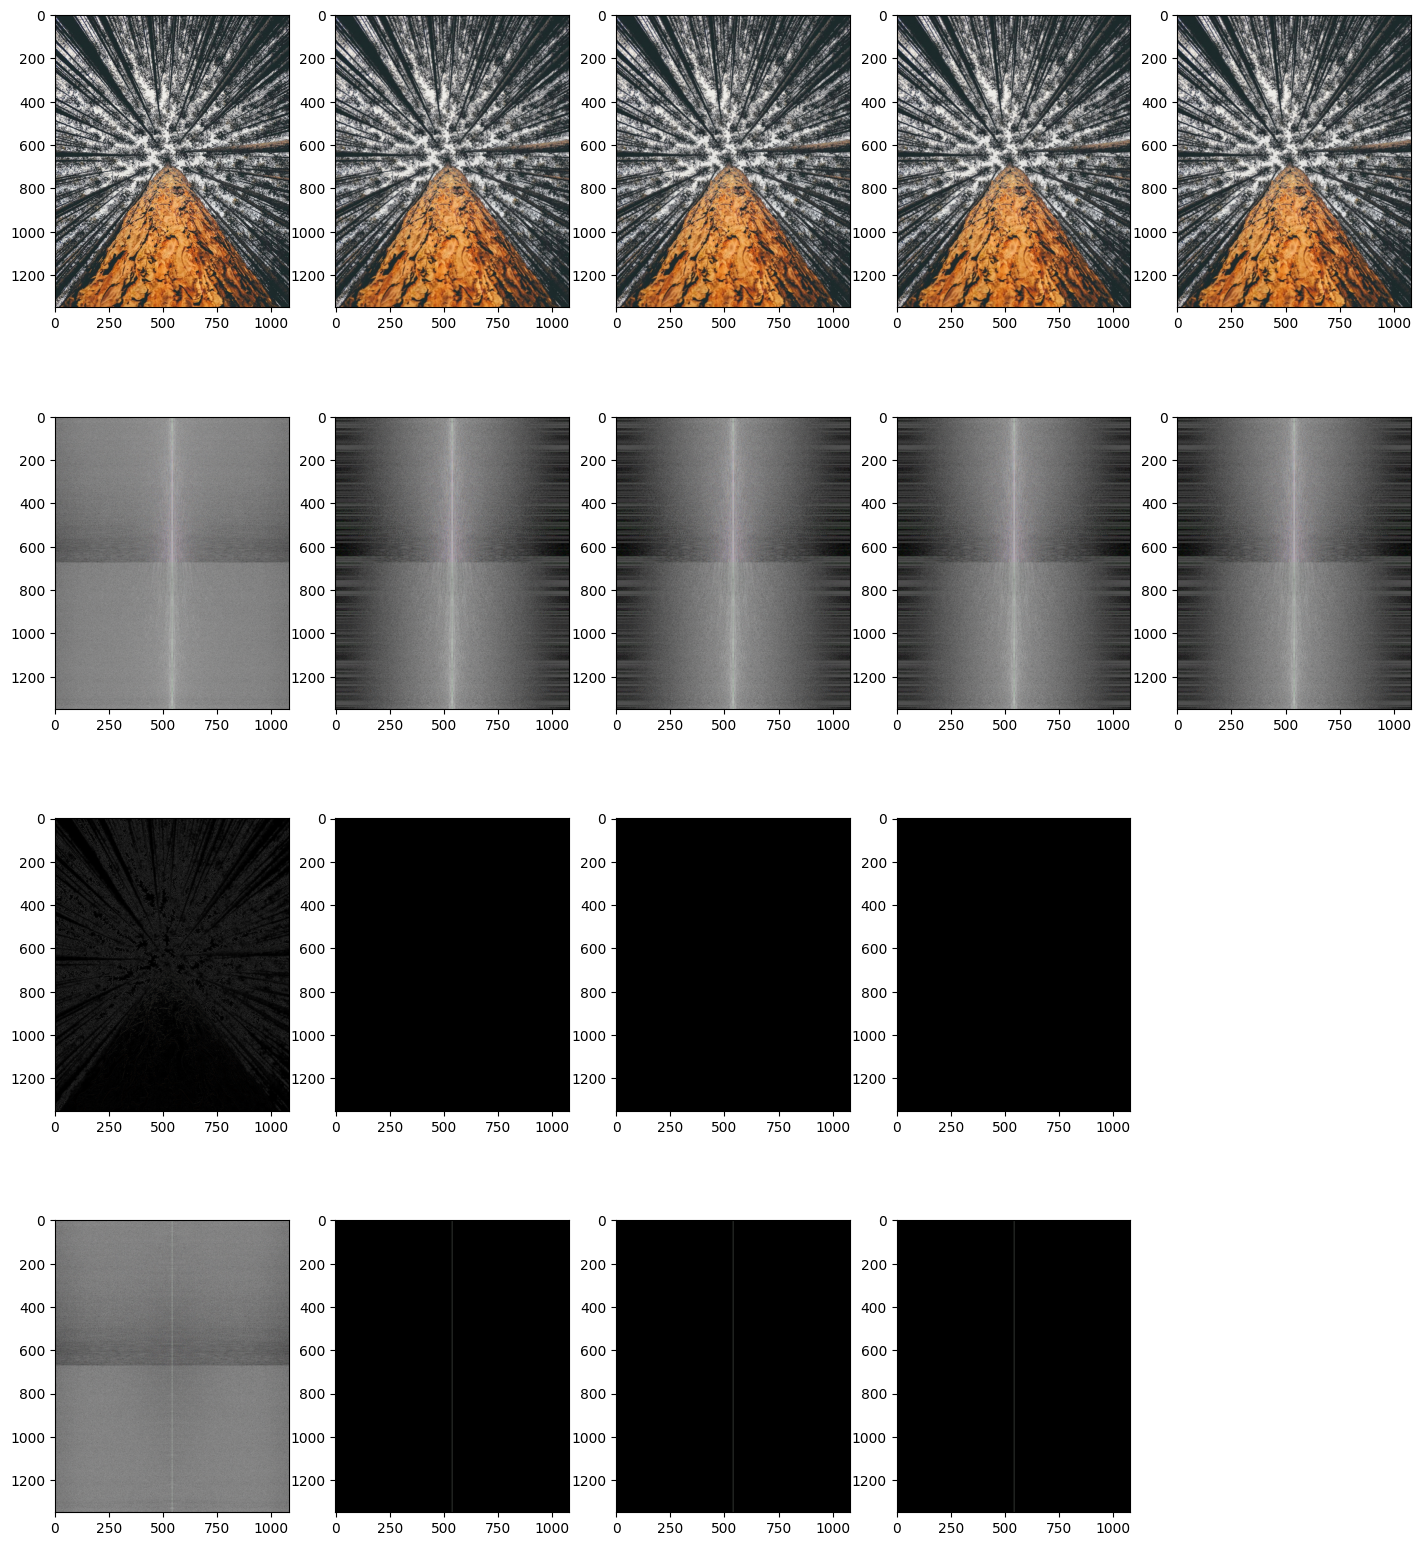

In [4]:
image = imread("trees.jpg")

sigma = 1
gaussian_pyramid = get_gaussian_pyramid(image, sigma)
laplacian_pyramid = get_laplacian_pyramid(image, sigma)

show_grid([gaussian_pyramid,
          [freq(g) for g in gaussian_pyramid],
          laplacian_pyramid,
          [freq(l) for l in laplacian_pyramid]])

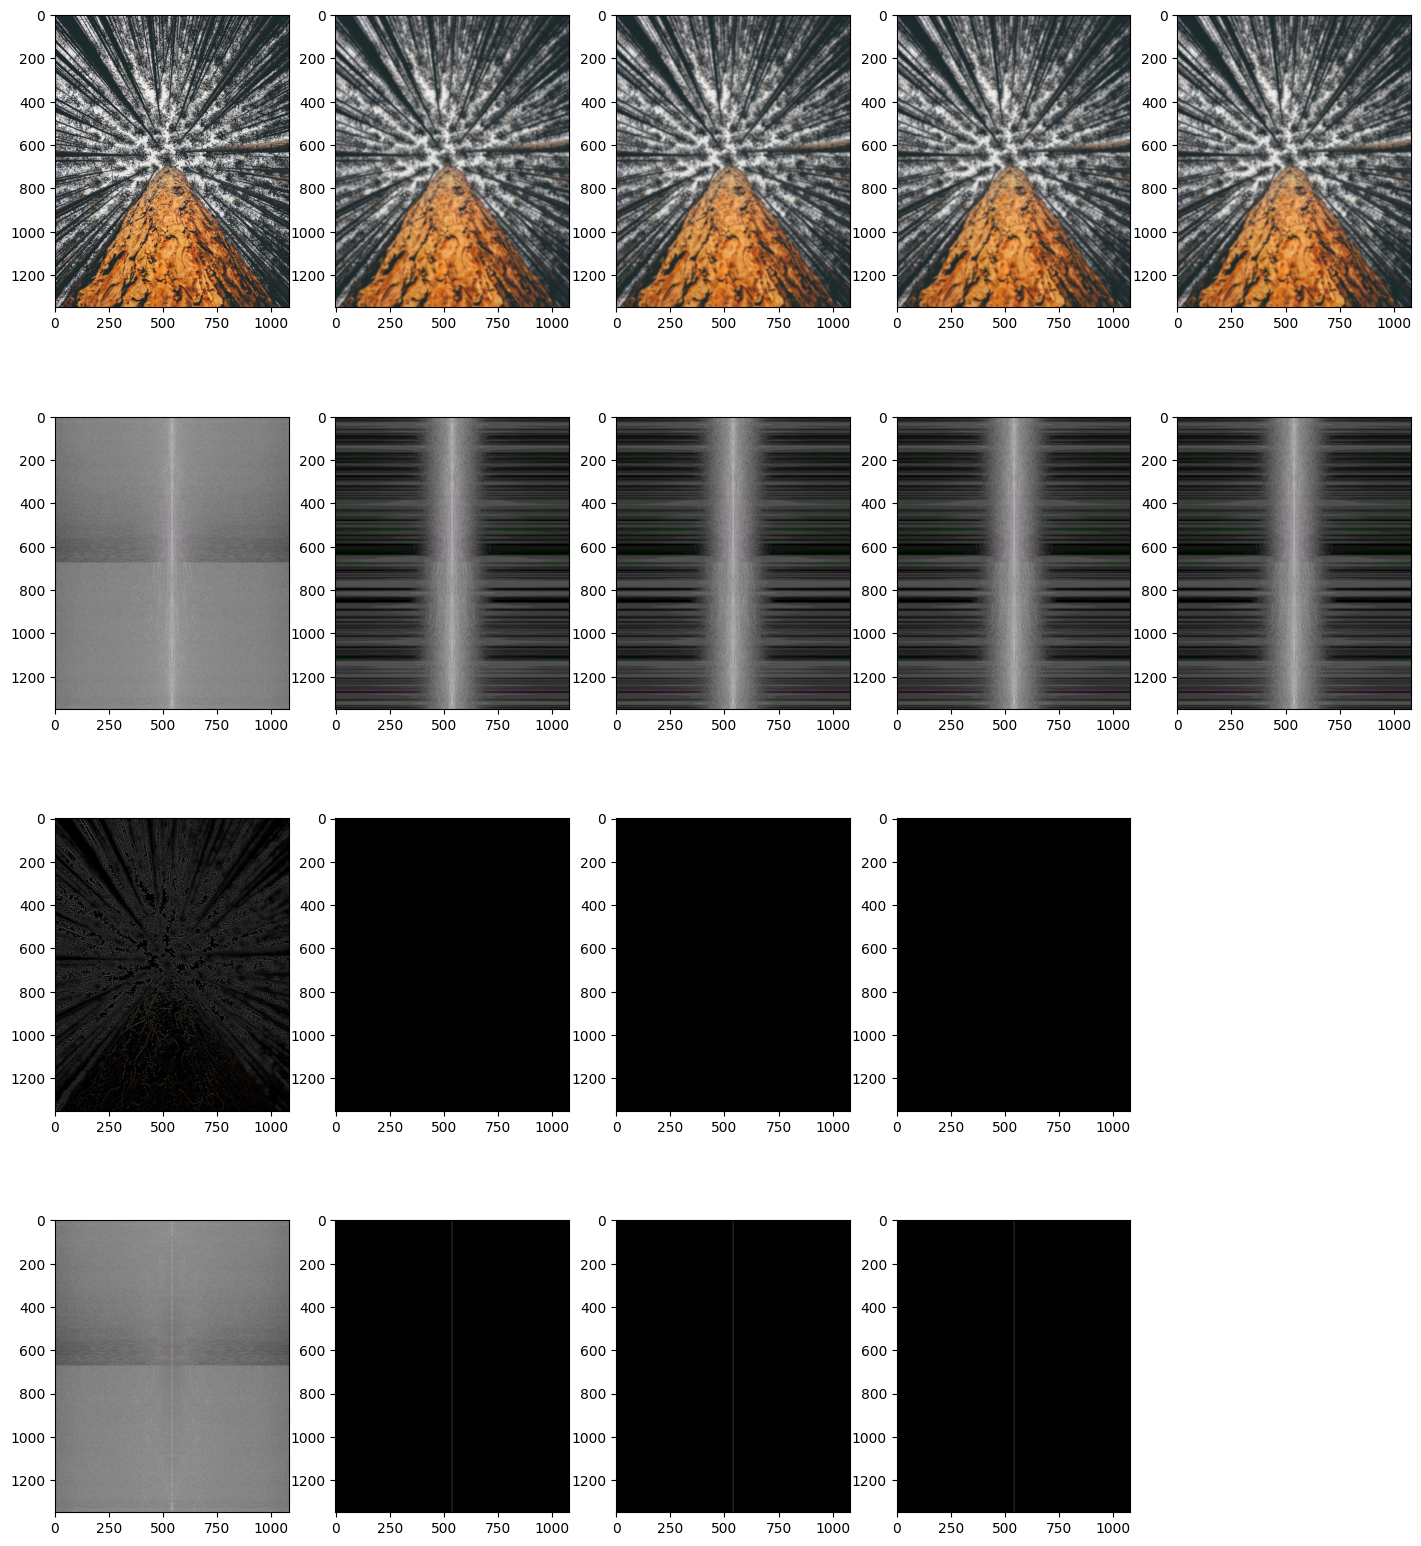

In [5]:
sigma = 3
gaussian_pyramid = get_gaussian_pyramid(image, sigma)
laplacian_pyramid = get_laplacian_pyramid(image, sigma)

show_grid([gaussian_pyramid,
          [freq(g) for g in gaussian_pyramid],
          laplacian_pyramid,
          [freq(l) for l in laplacian_pyramid]])

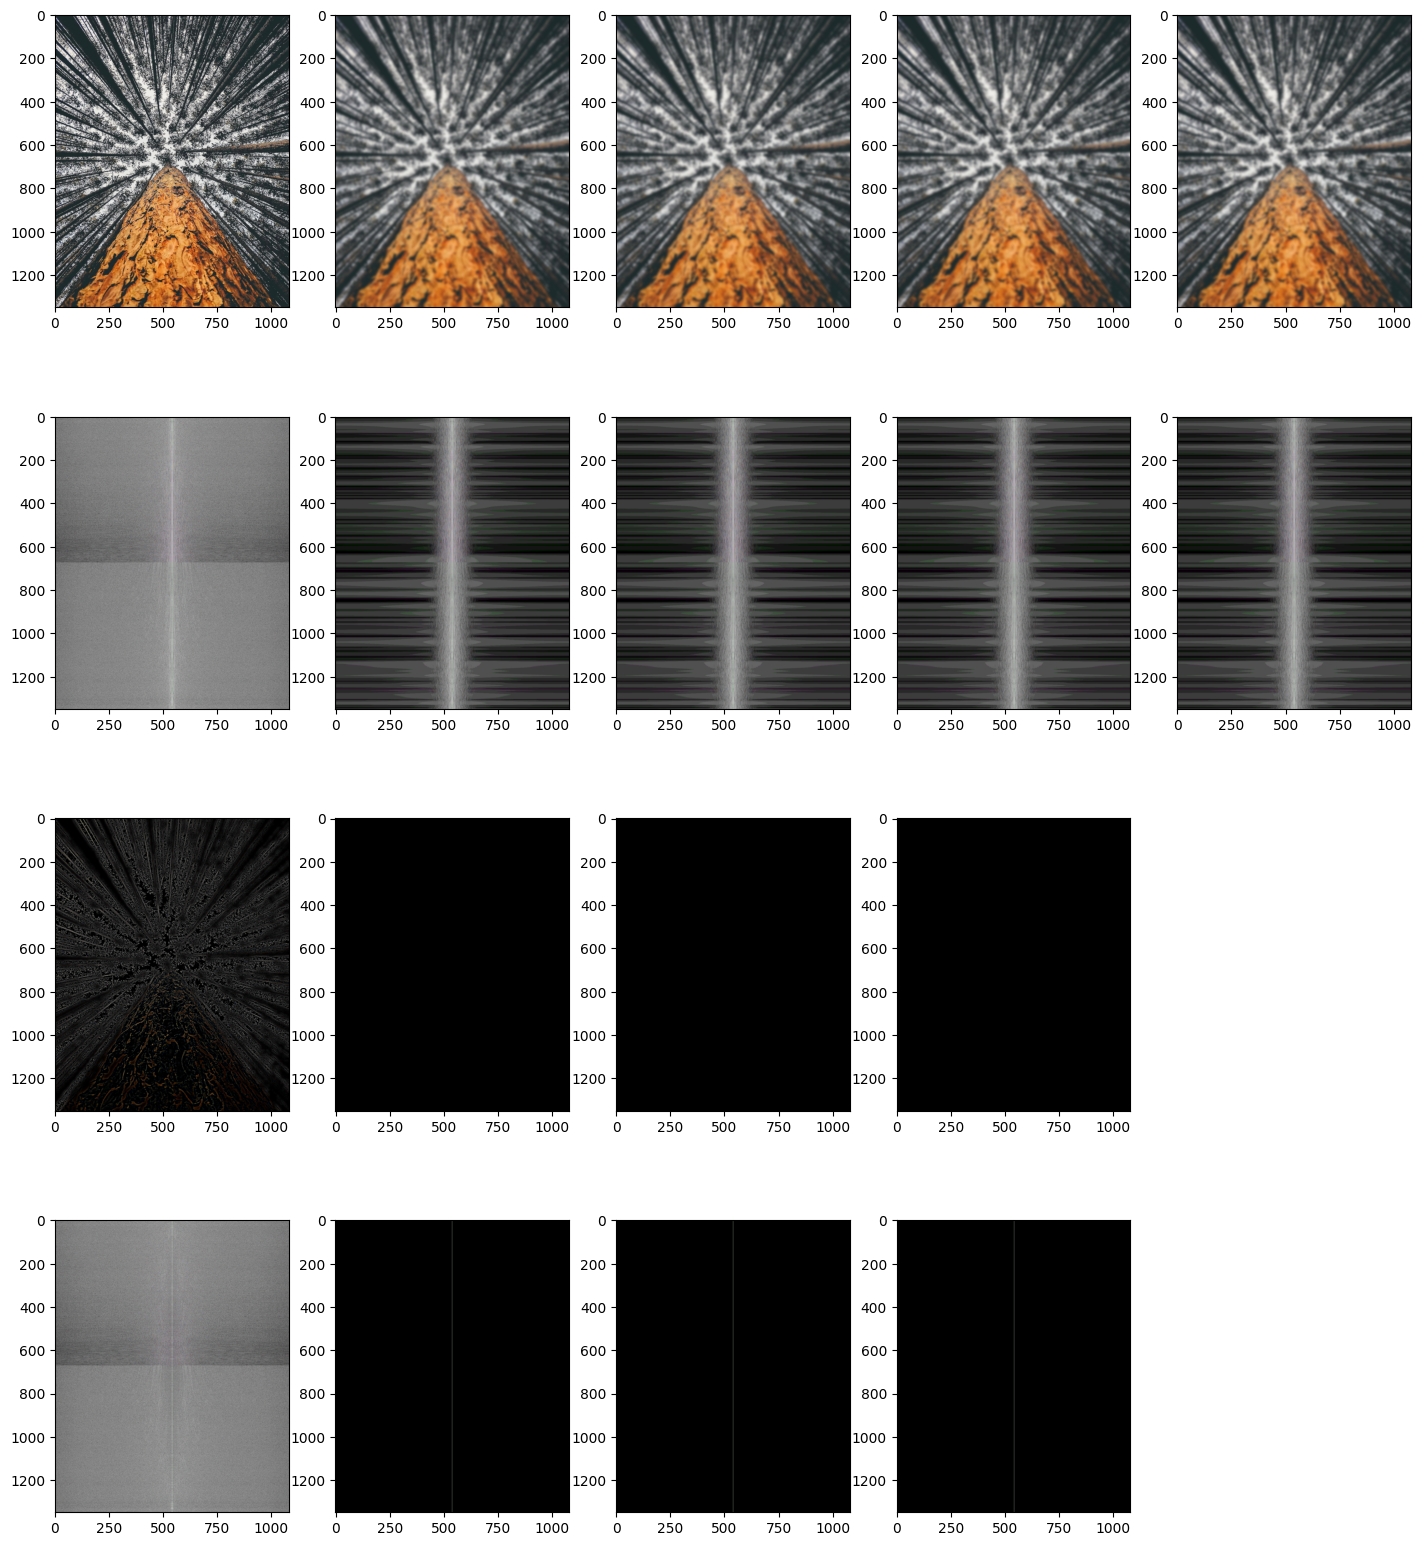

In [6]:
sigma = 5
gaussian_pyramid = get_gaussian_pyramid(image, sigma)
laplacian_pyramid = get_laplacian_pyramid(image, sigma)

show_grid([gaussian_pyramid,
          [freq(g) for g in gaussian_pyramid],
          laplacian_pyramid,
          [freq(l) for l in laplacian_pyramid]])

In [7]:
def blend(a, b, mask, sigma=1, n_layers=5):
    mask = img_as_float(mask > 128)

    la = np.array(get_laplacian_pyramid(a, sigma, n_layers, extend=True))
    lb = np.array(get_laplacian_pyramid(b, sigma, n_layers, extend=True))
    gm = np.array(get_gaussian_pyramid(mask, sigma, n_layers))

    pyramid = gm * la + (1 - gm) * lb

    image = np.clip(sum(pyramid), 0, 1)


    return image, pyramid

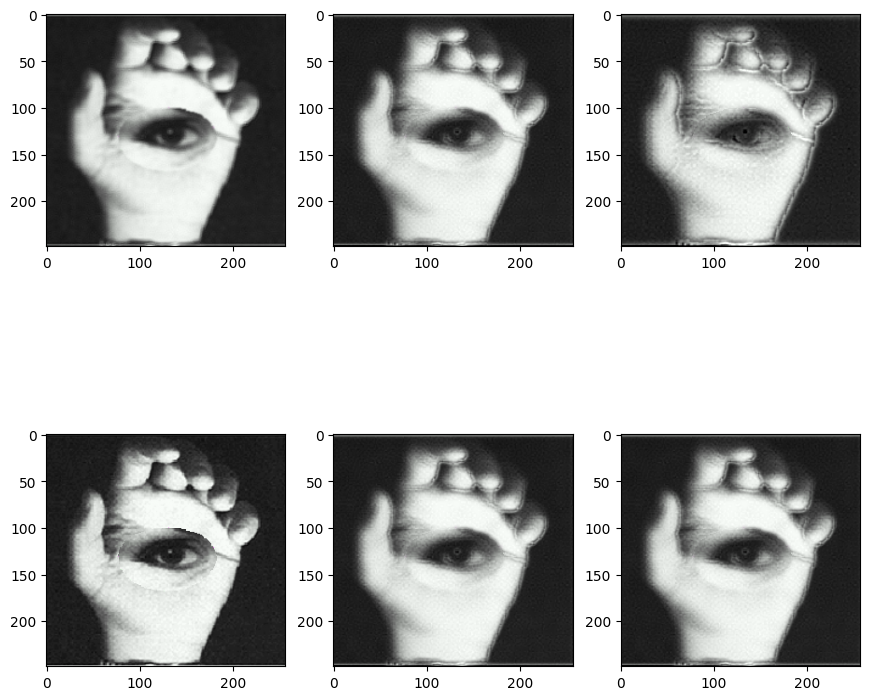

In [8]:
a = imread("a.png")
b = imread("b.png")
mask = imread("mask.png")


show_grid([
        [
          # fixed n_layers
          blend(a, b, mask, sigma=0.9, n_layers=5)[0],
          blend(a, b, mask, sigma=1.7, n_layers=5)[0],
          blend(a, b, mask, sigma=3.1, n_layers=5)[0],
        ],
        [
          # fixed sigma
          blend(a, b, mask, sigma=1.7, n_layers=1)[0],
          blend(a, b, mask, sigma=1.7, n_layers=3)[0],
          blend(a, b, mask, sigma=1.7, n_layers=15)[0],
        ]
    ])

<ipython-input-18-46b3348f713c>:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(blend(a, b, mask, 0.47, 20)[0])


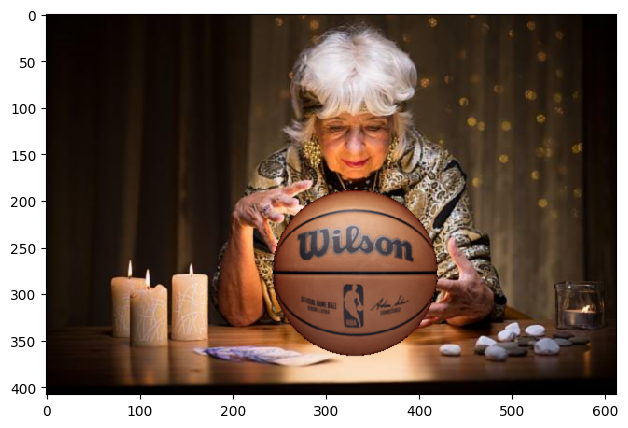

In [18]:
a = imread("a_1.png")[:, :, :3]
b = imread("b_1.png")
mask = imread("mask_1.png")

imshow(blend(a, b, mask, 0.47, 20)[0])

<ipython-input-20-2b11cc954fa6>:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(blend(a, b, mask, sigma=0.47, n_layers=12)[0])


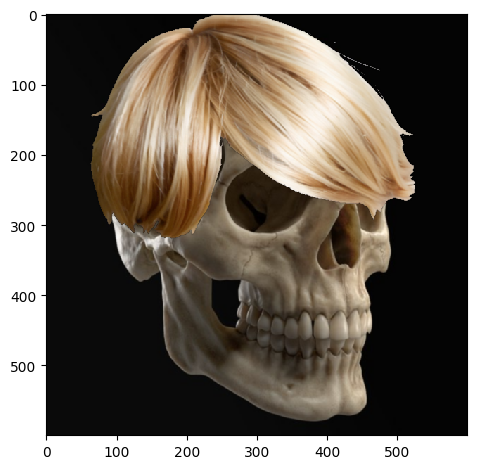

In [20]:
a = imread("a_2.png")[:, :, :3]
b = imread("b_2.jpg")
mask = imread("mask_2.jpg")
imshow(blend(a, b, mask, sigma=0.47, n_layers=12)[0])

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
<ipython-input-11-b85e11079e86>:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(blend(a, b, mask, sigma=0.8, n_layers=7)[0])


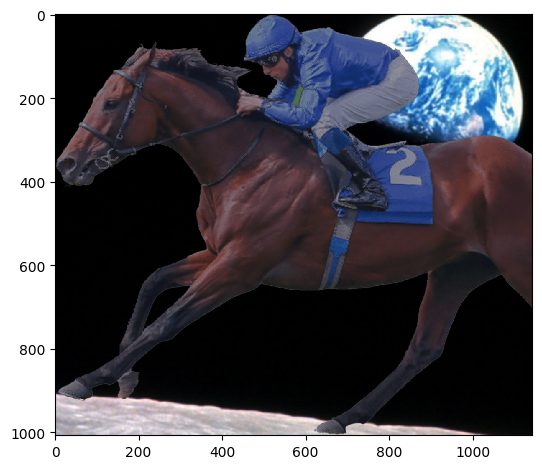

In [11]:
a = imread("a_3.png")[:, :, :3]
b = imread("b_3.png")
mask = imread("mask_3.png")
imshow(blend(a, b, mask, sigma=0.8, n_layers=7)[0])